# Необходимо реализовать мехинизм вычисления метки подынтервалу (подокну) (при перекрытии окон при разбиении) на основе ответов модели
 1) Суммарное агрегирование для подынтервала
 2) Среднее арифметическое вероятности в зависимости от дистанции (от центра окна). Так как свёрточная сеть лучше работает на серидине окна (проблемы с краями) 

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().absolute().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.time_series import load_multi_csv, load_angles
from src.sliding_window import sliding_windows_multiplet
from src.inference import load_model, predict_multiplet, predict_classes_from_proba
from src.visual import plot_raw_multiplet, plot_multiplet_predictions, plot_angles
from src.criteria import process_multiplet

2026-05-05 19:08:48.688369: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
data_path=str(PROJECT_ROOT)+'/time_series/TOI-1136_arg_p_max_history_resonance_3_2_between_1_and_2_original_angles.npz'
data = load_angles(data_path, ['phi_0_original', 'phi_1_original'], time_column='time_years',convert_to_xy=True)

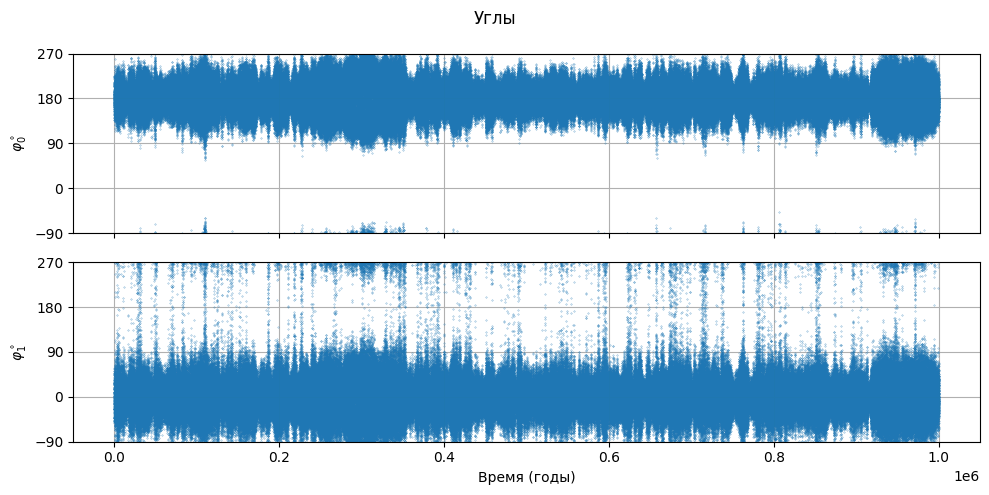

In [4]:
plot_angles(data['time_years'], data['angles_deg'], title='Углы')

In [5]:
windows = sliding_windows_multiplet(
    data_dict=data,
    window_length=4000,
    overlap_ratio=0.5
)

In [6]:
model = load_model('1', models_dir=str(PROJECT_ROOT)+'/models/')
# probs = predict_multiplet(windows['angle_windows'], model)
# classes = [predict_classes_from_proba(p) for p in probs]

W0000 00:00:1777990133.770768  227665 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
probs = predict_multiplet(windows['angle_windows'], model)
# classes = [predict_classes_from_proba(p) for p in probs]

In [25]:
probs[0].shape

(199, 3)

In [8]:
classes = [predict_classes_from_proba(p) for p in probs]

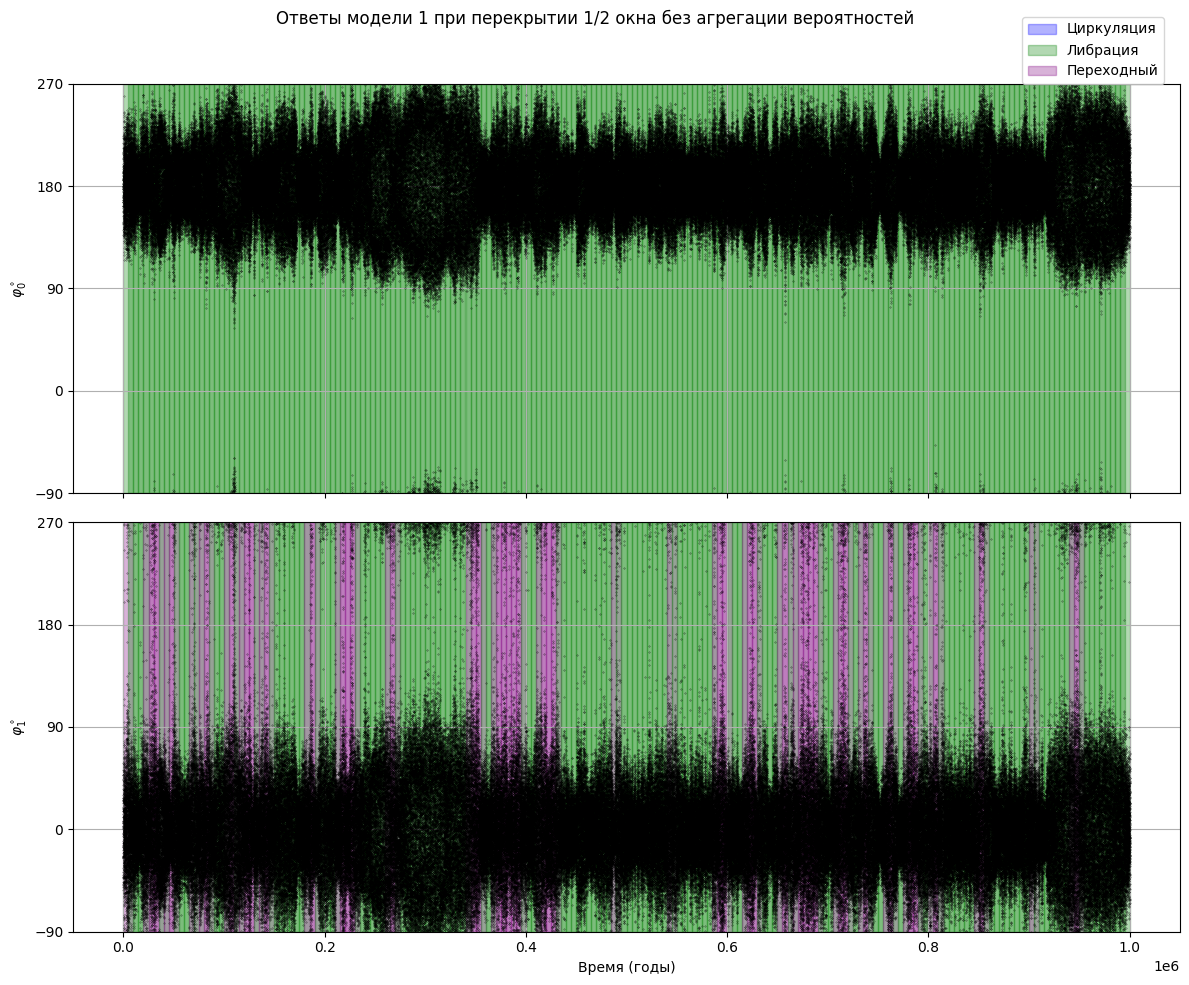

In [10]:
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes,
    title='Ответы модели 1 при перекрытии 1/2 окна без агрегации вероятностей',
    angle_min=-90., #Диапазоны нормализации угла
    angle_max=270.,
    fig_width=12.,
    row_height=5.,
    # save_path='/content/drive/MyDrive/Diplom_data/resonance_sorter/notebook/predict_TOI1136_model1.png'

)

На самый первый подынтервал $1$ и последний $N$ приходится по одному прогнозу от модели. На все остальные по 2. То есть:
\begin{equation}
\begin{split}
& F_{p_n} \in [f_N,f_{N+1}], F_{p_n} \ne F_{p_1} \lor F_{p_N}, \\
& F_{p_1} \in [f_1], \\
& F_{p_N} \in [f_N], \\
\end{split}
\end{equation}

где $F_{p_n}$ $-$ подынтервал, $f_N$ $-$ окно разбиения. При перекрытии окон разбиения в $1/2$ окна, получается $2n-1$ окон, если исходный ряд разбивался на $n$ окон (без перекрытий). Подынтервалов, соответственно $2n$, из которых $2$, получат по одному прогнозу, а $2(n-1)$ $-$ по $2$ прогноза.

In [12]:
from src.agregate import average_overlapping_probs #грубые вероятности

In [13]:
sub_data = average_overlapping_probs(probs, windows['window_bounds'])

In [26]:
# sub_data

In [16]:
sub_data['probs']

[array([[2.22205858e-06, 9.99995172e-01, 2.53725193e-06],
        [3.19132096e-06, 9.99994278e-01, 2.45998081e-06],
        [6.94330265e-06, 9.99989629e-01, 3.32771242e-06],
        [9.31867180e-06, 9.99983966e-01, 6.63432866e-06],
        [4.65820358e-06, 9.99982178e-01, 1.31396428e-05],
        [2.40644454e-07, 9.99984503e-01, 1.51934601e-05],
        [4.69193679e-07, 9.99991953e-01, 7.52381311e-06],
        [1.96504357e-06, 9.99996662e-01, 1.32502294e-06],
        [6.36257300e-06, 9.99980688e-01, 1.28633928e-05],
        [8.64872891e-06, 9.99935269e-01, 5.60367662e-05],
        [4.56583211e-06, 9.99948978e-01, 4.63808101e-05],
        [1.76912886e-06, 9.99994516e-01, 3.60099284e-06],
        [2.28278077e-06, 9.99989510e-01, 8.15591193e-06],
        [2.33061132e-06, 9.99971509e-01, 2.61069745e-05],
        [1.74770400e-06, 9.99977469e-01, 2.07204284e-05],
        [8.53234326e-07, 9.99994874e-01, 4.21222694e-06],
        [4.88343176e-07, 9.99990523e-01, 8.93524521e-06],
        [1.514

In [28]:
sub_data['probs'][0].shape # для первого угла мультиплета агрегированные для 2,3,4,...,n-2,n-1 окна

(199, 3)

In [27]:
probs[0].shape

(199, 3)

In [22]:
sub_data['probs'][1].shape # для второго угла мультиплета

(199, 3)

In [47]:
print(sub_data['probs'][0][0]) #[0][0] [0][1]    нелевое
print(sub_data['probs'][0][1]) #[0][1] [0][2]    #первое
print(sub_data['probs'][0][2]) #[0][2] [0][3]    второе
print(sub_data['probs'][0][3]) #[0][3] [0][4]    третье
print(sub_data['probs'][0][4]) #[0][4] [0][5]    четвертое
print(sub_data['probs'][0][5]) #[0][5] [0][6]    пятое

[2.2220586e-06 9.9999517e-01 2.5372519e-06]
[3.1913210e-06 9.9999428e-01 2.4599808e-06]
[6.9433027e-06 9.9998963e-01 3.3277124e-06]
[9.3186718e-06 9.9998397e-01 6.6343287e-06]
[4.6582036e-06 9.9998218e-01 1.3139643e-05]
[2.4064445e-07 9.9998450e-01 1.5193460e-05]


In [43]:
print(probs[0][0]) 
print(probs[0][1])
print(probs[0][2])
print(probs[0][3])
print(probs[0][4])
print(probs[0][5])
print(probs[0][6])

[2.2220586e-06 9.9999517e-01 2.5372519e-06]
[4.1605831e-06 9.9999338e-01 2.3827097e-06]
[9.726023e-06 9.999859e-01 4.272715e-06]
[8.9113219e-06 9.9998206e-01 8.9959422e-06]
[4.0508527e-07 9.9998230e-01 1.7283342e-05]
[7.6203662e-08 9.9998671e-01 1.3103579e-05]
[8.6218370e-07 9.9999720e-01 1.9440472e-06]


In [45]:
print(probs[0][0]) # нелевое
print((probs[0][0]+probs[0][1])/2.) #первое
print((probs[0][1]+probs[0][2])/2.) #второе
print((probs[0][2]+probs[0][3])/2.) #третье
print((probs[0][3]+probs[0][4])/2.) #четвертое
print((probs[0][4]+probs[0][5])/2.) #пятое

[2.2220586e-06 9.9999517e-01 2.5372519e-06]
[3.1913210e-06 9.9999428e-01 2.4599808e-06]
[6.9433027e-06 9.9998963e-01 3.3277124e-06]
[9.3186718e-06 9.9998397e-01 6.6343287e-06]
[4.6582036e-06 9.9998218e-01 1.3139643e-05]
[2.4064445e-07 9.9998450e-01 1.5193460e-05]


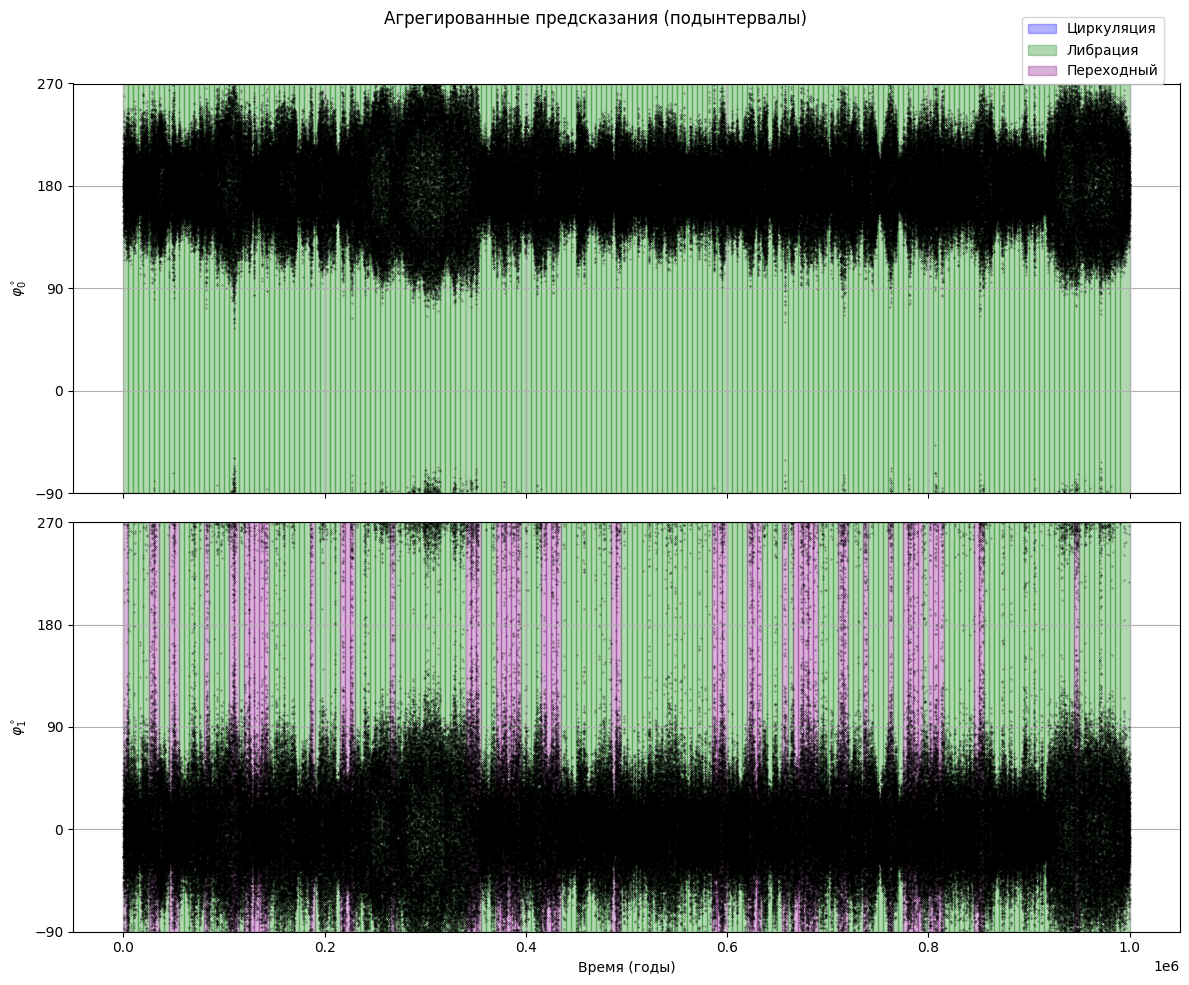

In [14]:
#та же модель 
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=sub_data['bounds'],
    class_labels_list=sub_data['classes'],
    title='Агрегированные предсказания (подынтервалы)',
    angle_min=-90., #Диапазоны нормализации угла
    angle_max=270.,
    fig_width=12.,
    row_height=5.,
    
)